# _**Machine Learning Project**_

## **Importing Libraries for this Project**

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## **Importing dataset**

In [47]:
df=pd.read_csv('C:\\Github repos\\Mental health score prediction\\Mental-Health-Score-Predictions\\Student Social Media And Mental Health Impact.csv')

## **Shape of the dataset**

In [48]:
df.shape

(5000, 13)

## **Applying statics functions**

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [50]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


## **Checking missing values in data**

In [51]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

## **Checking duplicates in data**

In [52]:
df.duplicated().sum()

2

## _Removing duplicates values_

In [53]:
df.drop_duplicates(inplace=True)

In [54]:
df.duplicated().sum()

0

## **Name of the columns**

In [55]:
df.columns.to_list()

['Age',
 'Gender',
 'Country',
 'Academic_Level',
 'Most_Used_Platform',
 'Purpose_Of_Use',
 'Avg_Daily_Usage_Hours',
 'Daily_Unlocks',
 'Study_Hours',
 'Physical_Activity_Hours',
 'Sleep_Hours_Per_Night',
 'Stress_Level',
 'Mental_Health_Score']

## **Heatmap to check the relation of the target column with others columns**

In [56]:
df_numerical = df.select_dtypes(include=[np.number])

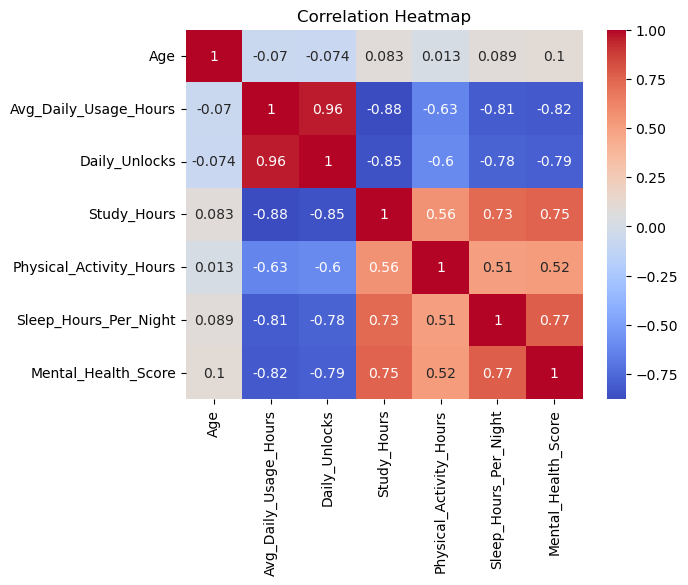

In [57]:
sns.heatmap(df_numerical.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## **Basic Eda with those column who have strong relation our target column**

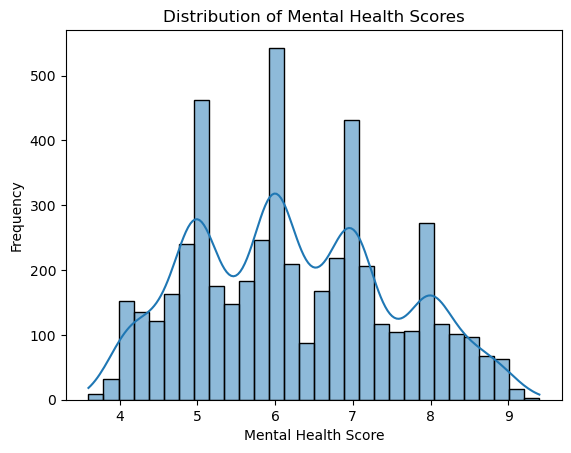

In [58]:
sns.histplot(data=df,x='Mental_Health_Score',bins=30,kde=True)
plt.title('Distribution of Mental Health Scores')
plt.xlabel('Mental Health Score')
plt.ylabel('Frequency')
plt.show()

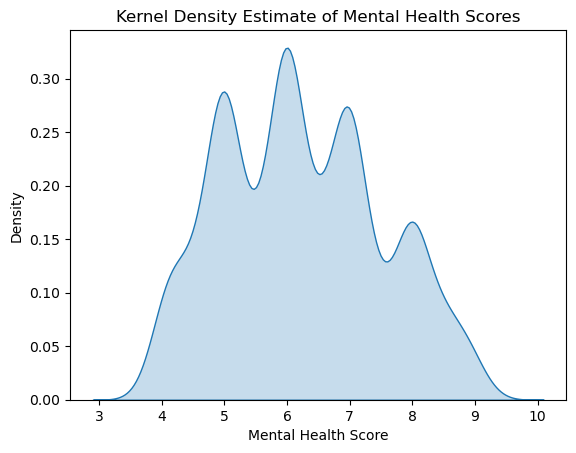

In [59]:
sns.kdeplot(data=df,x='Mental_Health_Score',fill=True)
plt.title('Kernel Density Estimate of Mental Health Scores')
plt.xlabel('Mental Health Score')
plt.ylabel('Density')
plt.show()

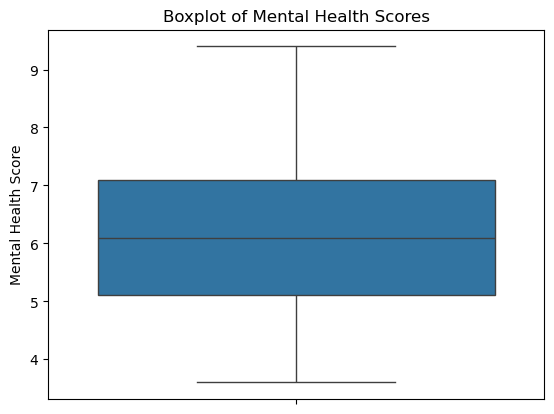

In [60]:
sns.boxplot(data=df, y='Mental_Health_Score')
plt.title('Boxplot of Mental Health Scores')
plt.ylabel('Mental Health Score')
plt.show()

In [61]:
df['Age'].value_counts()

Age
21    946
19    905
22    896
20    883
23    496
18    450
24    422
Name: count, dtype: int64

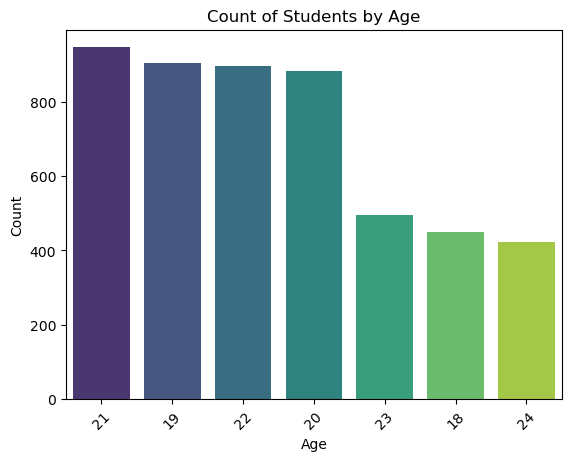

In [62]:
sns.countplot(data=df, x='Age', order=df['Age'].value_counts().index,palette='viridis')
plt.title('Count of Students by Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

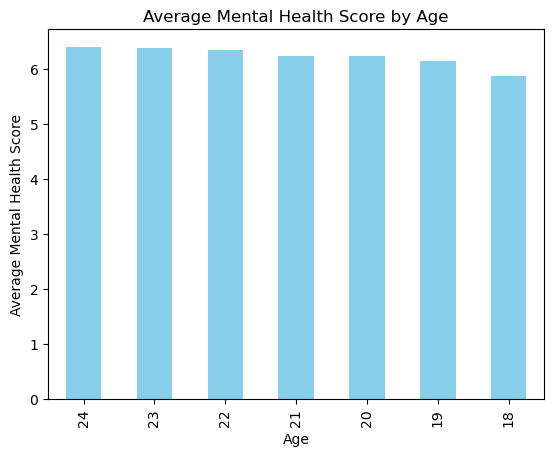

In [63]:
df.groupby('Age')['Mental_Health_Score'].mean().sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Average Mental Health Score by Age')
plt.xlabel('Age')
plt.ylabel('Average Mental Health Score')
plt.show()

In [64]:
df['Physical_Activity_Hours'].value_counts()

Physical_Activity_Hours
 1.6    305
 2.0    286
 1.8    280
 1.7    276
 1.9    267
 1.3    267
 1.5    266
 1.4    259
 1.2    246
 2.1    242
 2.2    237
 2.3    197
 1.1    194
 2.4    178
 2.5    172
 1.0    149
 0.9    133
 2.6    132
 2.7    120
 0.7    100
 2.9     91
 0.8     90
 2.8     81
 0.6     75
 0.5     50
 0.4     47
 3.1     46
 3.0     45
 3.2     38
 0.3     27
 0.2     20
 3.3     19
 3.4     18
 0.0     13
 3.6      9
 0.1      5
 3.5      5
-0.1      4
-0.2      3
-0.3      2
 3.7      1
 4.1      1
 3.8      1
-0.4      1
Name: count, dtype: int64

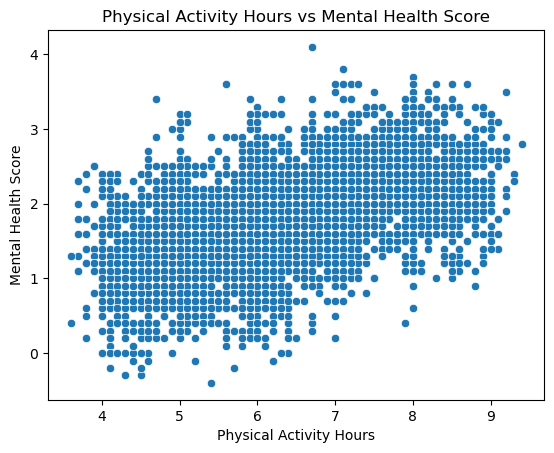

In [65]:
sns.scatterplot(data=df, y='Physical_Activity_Hours', x='Mental_Health_Score')
plt.title('Physical Activity Hours vs Mental Health Score')
plt.xlabel('Physical Activity Hours')
plt.ylabel('Mental Health Score')
plt.show()

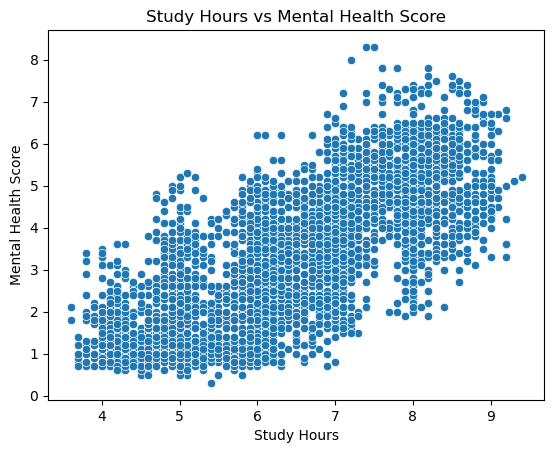

In [66]:
sns.scatterplot(data=df, y='Study_Hours', x='Mental_Health_Score')
plt.title('Study Hours vs Mental Health Score')
plt.xlabel('Study Hours')
plt.ylabel('Mental Health Score')
plt.show()

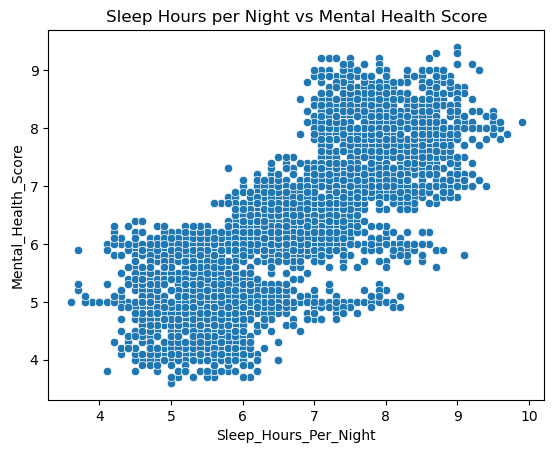

In [67]:
sns.scatterplot(data=df, x='Sleep_Hours_Per_Night', y='Mental_Health_Score')
plt.title('Sleep Hours per Night vs Mental Health Score')
plt.show()

In [68]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

<Axes: xlabel='Gender', ylabel='count'>

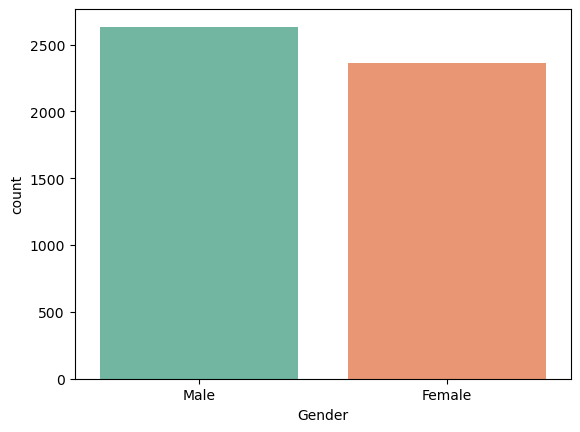

In [69]:
sns.countplot(data=df,x='Gender',palette='Set2')

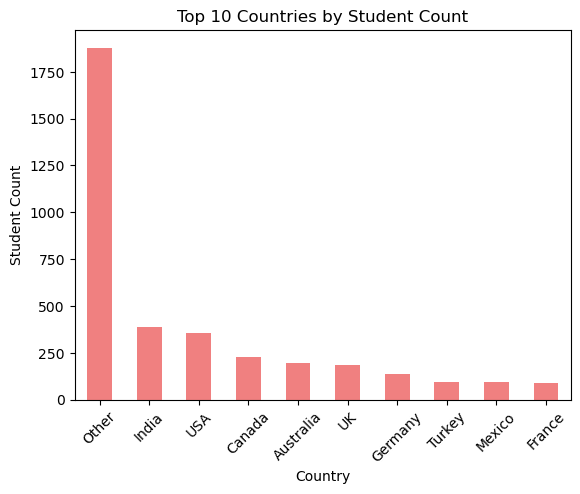

In [70]:
df['Country'].value_counts().head(10).plot(kind='bar', color='lightcoral')
plt.title('Top 10 Countries by Student Count')
plt.xlabel('Country')
plt.ylabel('Student Count')
plt.xticks(rotation=45)
plt.show()

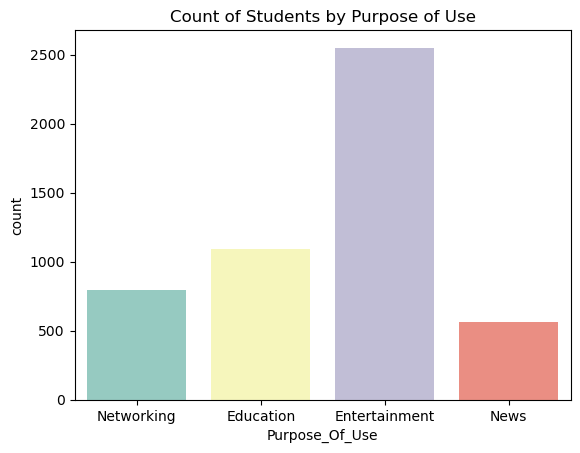

In [71]:
sns.countplot(data=df,x='Purpose_Of_Use',palette='Set3')
plt.title('Count of Students by Purpose of Use')
plt.show()

In [72]:
df_categorical = df.select_dtypes(include=[object])

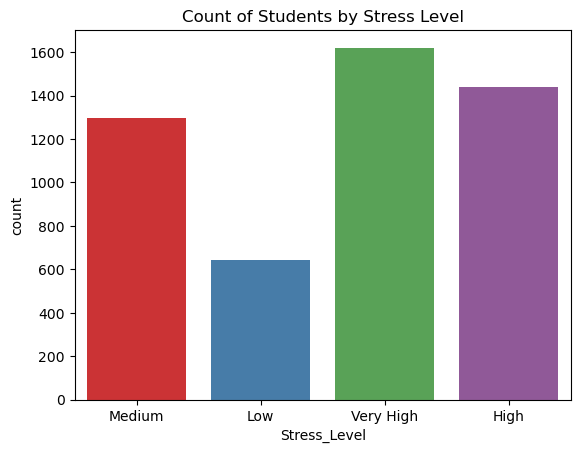

In [73]:
sns.countplot(data=df, x='Stress_Level', palette='Set1')
plt.title('Count of Students by Stress Level')
plt.show()

## **Train test split**

In [74]:
X = df.drop(columns=['Mental_Health_Score'])
Y=df['Mental_Health_Score']

In [75]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

## **Column Transformer**

In [76]:
num_features = X_train.select_dtypes(include=[np.number]).columns
cat_features = X_train.select_dtypes(include=[object]).columns

In [77]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
preprocces = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first',handle_unknown='ignore'), cat_features)
    ]
)

## **Importing model**

In [78]:
from xgboost import XGBRegressor
from sklearn.pipeline import make_pipeline


## **Making pipeline**

In [79]:
from sklearn.pipeline import make_pipeline
from xgboost import XGBRegressor

best_params = {
 'subsample': 0.7,          # kam kiya
    'reg_lambda': 5,           # regularization barhaya
    'reg_alpha': 3,
    'n_estimators': 500,
    'max_depth': 4,            # 10 se bohot kam
    'learning_rate': 0.03,     # 0.5 se bohot kam
    'colsample_bytree': 0.6,   # kam kiya
    'min_child_weight': 5  
}

makepipe = make_pipeline(
    preprocces,
    XGBRegressor(**best_params, random_state=42)
)

makepipe.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('xgbregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [80]:
y_pred = makepipe.predict(X_test)

In [81]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 0.26
Root Mean Squared Error (RMSE): 0.51
R-squared (R2): 0.86


In [82]:
test_r2_score = makepipe.score(X_test, Y_test)
train_r2_score = makepipe.score(X_train, Y_train)
print(f"Train R-squared (R2): {train_r2_score:.2f}")
print(f"Test R-squared (R2): {test_r2_score:.2f}")

Train R-squared (R2): 0.87
Test R-squared (R2): 0.86


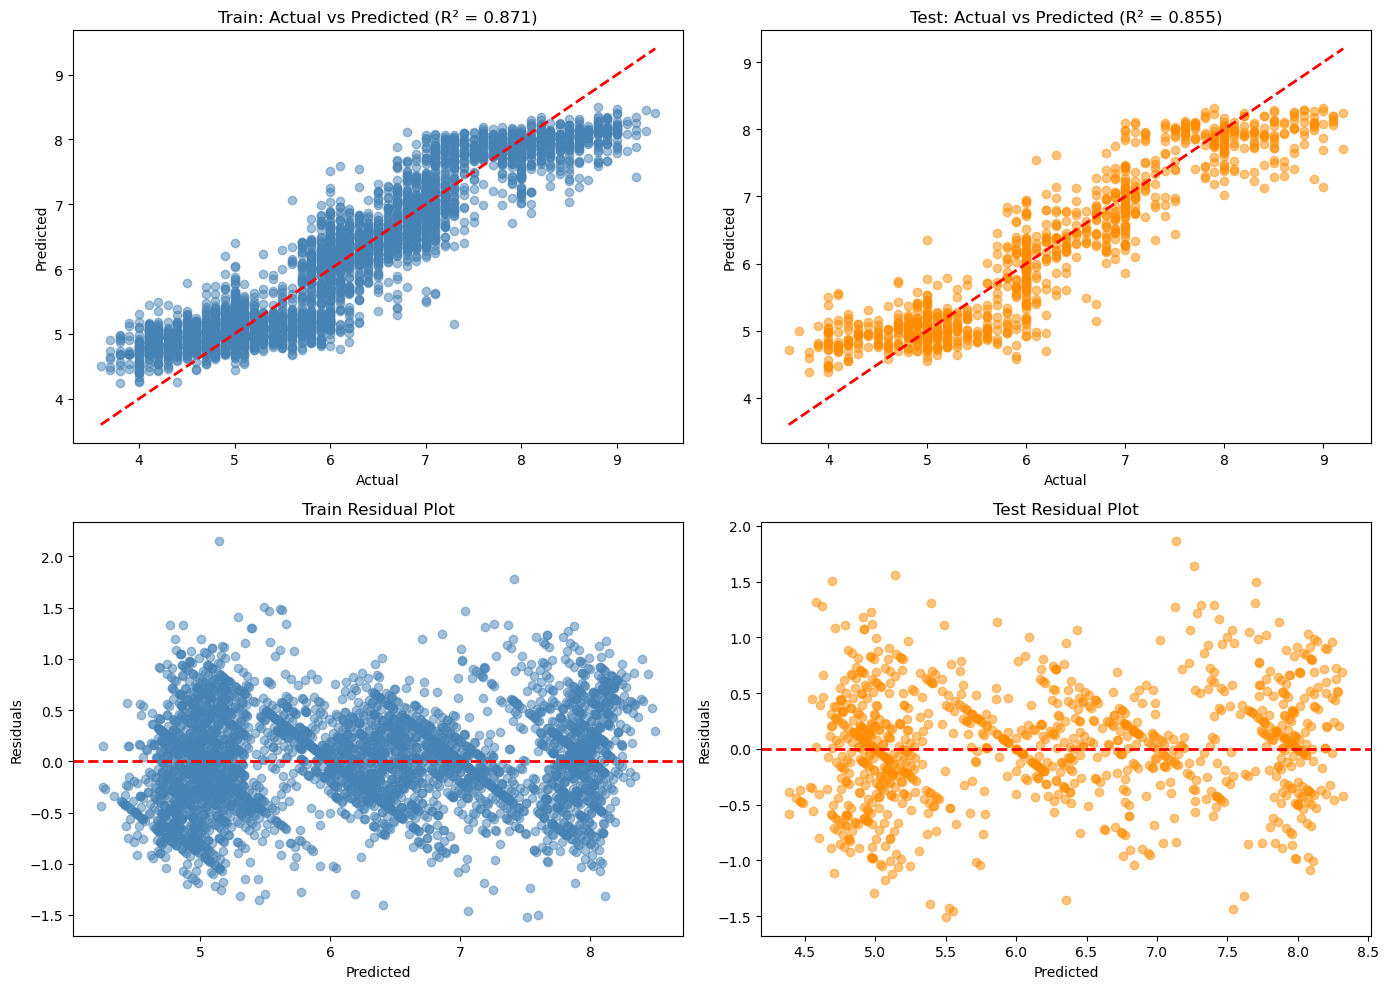

In [83]:
import matplotlib.pyplot as plt

train_pred = makepipe.predict(X_train)
test_pred = makepipe.predict(X_test)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Train: Actual vs Predicted
axes[0, 0].scatter(Y_train, train_pred, alpha=0.5, color='steelblue')
axes[0, 0].plot([Y_train.min(), Y_train.max()], [Y_train.min(), Y_train.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual')
axes[0, 0].set_ylabel('Predicted')
axes[0, 0].set_title(f'Train: Actual vs Predicted (R² = {r2_score(Y_train, train_pred):.3f})')

# 2. Test: Actual vs Predicted
axes[0, 1].scatter(Y_test, test_pred, alpha=0.5, color='darkorange')
axes[0, 1].plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Actual')
axes[0, 1].set_ylabel('Predicted')
axes[0, 1].set_title(f'Test: Actual vs Predicted (R² = {r2_score(Y_test, test_pred):.3f})')

# 3. Train Residuals
train_residuals = Y_train - train_pred
axes[1, 0].scatter(train_pred, train_residuals, alpha=0.5, color='steelblue')
axes[1, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title('Train Residual Plot')

# 4. Test Residuals
test_residuals = Y_test - test_pred
axes[1, 1].scatter(test_pred, test_residuals, alpha=0.5, color='darkorange')
axes[1, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('Test Residual Plot')

plt.tight_layout()
plt.show()

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4998 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4998 non-null   int64  
 1   Gender                   4998 non-null   object 
 2   Country                  4998 non-null   object 
 3   Academic_Level           4998 non-null   object 
 4   Most_Used_Platform       4998 non-null   object 
 5   Purpose_Of_Use           4998 non-null   object 
 6   Avg_Daily_Usage_Hours    4998 non-null   float64
 7   Daily_Unlocks            4998 non-null   int64  
 8   Study_Hours              4998 non-null   float64
 9   Physical_Activity_Hours  4998 non-null   float64
 10  Sleep_Hours_Per_Night    4998 non-null   float64
 11  Stress_Level             4998 non-null   object 
 12  Mental_Health_Score      4998 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 546.7+ KB


In [ ]:
import joblib
joblib.dump(makepipe, 'mental_health_model.pkl')

['mental_health_model.pkl']